In [ ]:
A notebook for testing stable diffusion

In [ ]:
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
import sys, os
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
    print('Top of sys.path:', sys.path[0])

In [ ]:
import argparse
import json
import os
import wandb
from functools import partial

import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from data_utils import  TargetReferenceDataset, collate_prompts
from torchvision.transforms.functional import to_pil_image
import numpy as np
from transformers import CLIPTextModel, CLIPTokenizer
import torch
from tqdm import tqdm
from ldm.models.diffusion.ddimcopy import DDIMSampler
from utils import get_models, print_trainable_parameters, set_seed

In [ ]:
model_orig, sampler_orig, model, sampler = get_models(
    "../configs/stable-diffusion/v1-inference.yaml", "../models/sd-v1-4.ckpt", "cuda"
)

In [ ]:
def encode(text: str):
    return (
        tokenizer(
            text,
            max_length=tokenizer.model_max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
            .to('cuda')
            .input_ids
    )


In [ ]:
import torch

# --- helpers ---
def l2norm(t, eps=1e-12):
    return t / torch.clamp(t.norm(dim=-1, keepdim=True), min=eps)

@torch.no_grad()
def embed_text(text: str) -> torch.Tensor:
    """Encode a prompt -> (D,) CLIP text embedding (float, L2-normalized)."""
    out = clip_text_encoder(encode(text)).pooler_output  # (1, D)
    return l2norm(out.squeeze(0).float())

@torch.no_grad()
def embed_keys(phrases: dict, keys: list[str]) -> torch.Tensor:
    """Stack embeddings for the given keys (skips missing). Returns (n, D)."""
    vecs = []
    for k in keys:
        if k in phrases:
            vecs.append(embed_text(phrases[k]))
        else:
            print(f"[warn] missing phrase key: {k} (skipped)")
    if not vecs:
        raise ValueError("No valid keys to embed.")
    return torch.stack(vecs, dim=0)

# --- your phrase bank (from the prompt) ---
phrases = {
    "target": "a photo of the deer",
    "buck": "a photo of the freight buck",
    "fawn": "a photo of the fawn",
    "fallow": "a photo of the fallow deer",                 # German for truck
    "frog": "a photo of the frog",               # out-of-class example (exclude)
    "rig": "a photo of the rig",
    "red": "a photo of the red deer",
    "reindeer": "a photo of the reindeer",
    "moose": "a photo of the moose",
    "stag": "a photo of the stag",
    "hart": "a photo of the hart",
    # add more car-specific prompts here if you like:
    "boar": "a photo of the boar",
    "squirrel": "a photo of the squirrel",
    "bear": "a photo of a bear",
    "dog": "a photo of a sports dog",
}

tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-large-patch14")
clip_text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-large-patch14").to('cuda').eval()


# --- choose which keys go to each class ---
truck_keys   = ["target","buck","fawn","fallow","red", "reindeer"]
vehicle_keys = ["moose", "boar", "squirrel", "bear"]  # extend with sedan/hatchback/sports/etc. if available

# --- build class clouds ---
E_truck   = embed_keys(phrases, truck_keys)     # (n_truck, D)
E_vehicle = embed_keys(phrases, vehicle_keys)   # (n_vehicle, D)

# --- class centroids (unit length) ---
c_truck   = l2norm(E_truck.mean(dim=0, keepdim=True))     # (1, D)
c_vehicle = l2norm(E_vehicle.mean(dim=0, keepdim=True))   # (1, D)

# --- compute "vehicle-ness" direction from union via PCA (top PC) ---
with torch.no_grad():
    X_union = torch.cat([E_truck, E_vehicle], dim=0)      # (n_all, D)
    X_mu = X_union.mean(dim=0, keepdim=True)
    Xc = X_union - X_mu
    # compact SVD on centered union
    U, S, Vh = torch.linalg.svd(Xc, full_matrices=False)  # Vh: (r, D), rows are PCs
    u_vehicle = Vh[0:1]                                   # (1, D) top PC = vehicle-ness

def project_out_vehicle(v: torch.Tensor) -> torch.Tensor:
    """
    Remove the component along the vehicle-ness direction u_vehicle.
    v: (..., D)
    """
    comp = (v @ u_vehicle.T) * u_vehicle                  # (..., 1) * (1, D) -> (..., D)
    return l2norm(v - comp)

# --- debiased centroids (optional but recommended) ---
c_truck_deb   = project_out_vehicle(c_truck)
c_vehicle_deb = project_out_vehicle(c_vehicle)

# --- scoring functions ---
@torch.no_grad()
def score_truck_vs_vehicle(x: torch.Tensor) -> torch.Tensor:
    """Raw (biased) difference-of-cosines: + means truck."""
    x = l2norm(x)
    return (x @ c_truck.T) - (x @ c_vehicle.T)

@torch.no_grad()
def score_truck_vs_vehicle_debiased(x: torch.Tensor) -> torch.Tensor:
    """Debiased score after removing vehicle-ness component."""
    x_ = project_out_vehicle(l2norm(x))
    return (x_ @ c_truck_deb.T) - (x_ @ c_vehicle_deb.T)

print("E_truck:",   tuple(E_truck.shape))
print("E_vehicle:", tuple(E_vehicle.shape))


In [ ]:
import torch

# --- knobs you can tweak ---
POOL = 128          # how many to sample before filtering
KEEP = 64           # how many final truckish samples to keep
QS   = 3            # remove top q shared PCs (1..3 usually)
SCALE = 0.3         # sampler spread (<1 tighter, >1 wider)
MARGIN_RAW = 0.02   # require raw >= margin
MARGIN_DEB = 0.02   # require debiased >= margin
PUSH =  0.25         # blend toward c_truck (0..1); 0 = no push

def l2norm(t, eps=1e-12): return t / torch.clamp(t.norm(dim=-1, keepdim=True), min=eps)
PUSH
@torch.no_grad()
def truck_specific_pca_model(E_truck: torch.Tensor, E_vehicle: torch.Tensor, q_shared: int = 1):
    T = l2norm(E_truck); V = l2norm(E_vehicle)
    X = torch.cat([T, V], dim=0)
    Xc = X - X.mean(0, keepdim=True)
    _, _, Vh_u = torch.linalg.svd(Xc, full_matrices=False)
    q = min(q_shared, Vh_u.shape[0])
    U_s = Vh_u[:q]
    P_perp = torch.eye(U_s.shape[1], device=U_s.device, dtype=U_s.dtype) - U_s.T @ U_s
    T_spec = T @ P_perp
    mu = T_spec.mean(0, keepdim=True)
    Tc = T_spec - mu
    _, S_t, Vh_t = torch.linalg.svd(Tc, full_matrices=False)
    eig = (S_t**2) / max(T.shape[0]-1, 1)
    return {"mu": mu, "Vh": Vh_t, "eig": eig}

@torch.no_grad()
def sample_truck_specific_pca(n: int, mdl, k: int = None, scale: float = 1.0):
    mu, Vh, eig = mdl["mu"], mdl["Vh"], mdl["eig"]
    r = Vh.shape[0]
    k = r if k is None else min(k, r)
    std = torch.sqrt(torch.clamp(eig[:k], min=1e-12)) * scale
    z = torch.randn(n, k, device=Vh.device, dtype=Vh.dtype) * std
    X = mu + (z @ Vh[:k])
    return l2norm(X)

# quality-controlled truckness sampler
@torch.no_grad()
def sample_truckness_qc(E_truck, E_vehicle, c_truck, c_vehicle,
                        pool=POOL, keep=KEEP, q_shared=QS, scale=SCALE,
                        margin_raw=MARGIN_RAW, margin_deb=MARGIN_DEB, push=PUSH):
    mdl = truck_specific_pca_model(E_truck, E_vehicle, q_shared=q_shared)
    X = sample_truck_specific_pca(pool, mdl, k=None, scale=scale)        # (pool, D)

    # optional push toward truck centroid to increase raw score
    if push > 0:
        X = l2norm((1.0 - push) * X + push * l2norm(c_truck))

    # scores
    raw  = (l2norm(X) @ c_truck.T) - (l2norm(X) @ c_vehicle.T)           # (pool,1)
    deb  = score_truck_vs_vehicle_debiased(X)                            # (pool,1)
    raw  = raw.squeeze(-1); deb = deb.squeeze(-1)

    # filters: both raw and debiased should be positive with margins
    keep_mask = (raw >= margin_raw) & (deb >= margin_deb)
    X_keep = X[keep_mask]
    raw_keep = raw[keep_mask]

    # if too few pass, relax gracefully: fallback to top raw
    if X_keep.shape[0] < keep:
        idx = torch.topk(raw, k=min(keep, raw.numel())).indices
        X_keep = X[idx]
        raw_keep = raw[idx]

    # final selection: top-K by raw
    idx = torch.topk(raw_keep, k=min(keep, raw_keep.numel())).indices
    return l2norm(X_keep[idx])

# ---- use it ----
# assumes: E_truck, E_vehicle, c_truck, c_vehicle, score_truck_vs_vehicle_debiased, phrases, embed_text exist
X_samp = sample_truckness_qc(E_truck, E_vehicle, c_truck, c_vehicle)

# ---- add to your table and sort by RAW ----
def eval_one(v: torch.Tensor):
    v = v.detach()
    raw  = float(((l2norm(v) @ c_truck.T) - (l2norm(v) @ c_vehicle.T)).item())
    deb  = float(score_truck_vs_vehicle_debiased(v))
    s_tr = float((l2norm(v) @ c_truck.T).item())
    s_vh = float((l2norm(v) @ c_vehicle.T).item())
    return raw, deb, s_tr, s_vh

keys_to_eval = [
    "target","buck","fawn","fallow","red", "reindeer",
    "moose", "boar", "squirrel", "bear", "dog", "stag", "hart"
]

print('!!! ', X_samp.shape)

out_dir = "deer_samples"
os.makedirs(out_dir, exist_ok=True)

# 2) Save tensor (CPU, .pt)
save_path = os.path.join(out_dir, f"X_samp_{X_samp.shape[0]}x{X_samp.shape[1]}.pt")
torch.save(X_samp.detach().cpu(), save_path)

print(f"[OK] Saved tensor to: {save_path}")

rows = []
with torch.no_grad():
    # phrases
    for k in keys_to_eval:
        if k in phrases:
            v = embed_text(phrases[k])
            rows.append((k, *eval_one(v)))
    # sampled
    for i, v in enumerate(X_samp, 1):
        rows.append((f"samp_truckQC_{i:02d}", *eval_one(v)))

# sort by RAW (desc) and print
rows.sort(key=lambda t: t[1], reverse=True)
hdr = f"{'key':>16s}  {'raw':>10s}  {'debiased':>10s}  {'cos(truck)':>11s}  {'cos(vehicle)':>12s}"
print(hdr); print("-"*len(hdr))
for k, raw, deb, s_tr, s_veh in rows:
    print(f"{k:>16s}  {raw:>10.4f}  {deb:>10.4f}  {s_tr:>11.4f}  {s_veh:>12.4f}")

In [ ]:
def generate_and_save_sd_images(
    model,
    sampler,
    prompt: str,
    device: torch.device,
    steps: int = 50,
    eta: float = 0.0,
    batch_size: int = 1,
    out_dir: str = "tmp",
    prefix: str = "unl_",
    start_code: torch.Tensor = None,   # optional noise tensor [B,4,64,64] (for 512x512)
):
    """
    Generates images with CFG from a CompVis SD model + DDIMSampler and saves them.

    - model: Stable Diffusion model (CompVis LDM style)
    - sampler: DDIMSampler(model)
    - prompt: text prompt
    - device: torch.device("cuda") or torch.device("cpu")
    - steps: DDIM steps
    - eta: DDIM eta (0.0 => deterministic)
    - batch_size: number of samples to generate
    - out_dir: folder to save into
    - prefix: file prefix, e.g., 'unl_'
    - start_code: optional start noise of shape [B, 4, H/8, W/8]; if None, sampled internally.
                  For 512×512 set shape to [B, 4, 64, 64].
    """
    # derive latent shape from start_code or default to 512×512
    if start_code is None:
        start_code = torch.randn(batch_size, 4, 64, 64, device=device)  # 512x512

    # freeze & eval for safety

    with torch.no_grad(), torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
        cond   = model.get_learned_conditioning([prompt] * start_code.shape[0])
        uncond = model.get_learned_conditioning([""] * start_code.shape[0])

        samples_latent, _ = sampler.sample(
            S=steps,
            conditioning={"c_crossattn": [cond]},
            batch_size=start_code.shape[0],
            shape=start_code.shape[1:],  # (4, H/8, W/8)
            verbose=False,
            unconditional_guidance_scale=7.5,                 # CFG scale; tweak if needed
            unconditional_conditioning={"c_crossattn": [uncond]},
            eta=eta,
            x_T=start_code,
        )

        # decode latents to [0,1] images
        imgs = model.decode_first_stage(samples_latent)       # [-1, 1]
        imgs = (imgs.clamp(-1, 1) + 1) / 2.0                 # [0, 1]

        # save
        out_path = Path(out_dir)
        out_path.mkdir(exist_ok=True)
        for i, im in enumerate(imgs.cpu()):
            im_u8 = (im.clamp(0, 1) * 255).round().to(torch.uint8)  # [3,H,W]
            to_pil_image(im_u8).save(out_path / f"{prefix}{i:04d}.png")

        print(f"Saved {len(imgs)} image(s) to {out_path}/ with prefix '{prefix}'")
        return imgs  # [B,3,H,W] in [0,1]

In [ ]:
sampler = DDIMSampler(model)

In [ ]:
img = generate_and_save_sd_images(
    model=model,
    sampler=sampler,
    prompt="a photo of the boar",
    device=torch.device("cuda"),
    steps=50,
    out_dir="tmp",
    prefix="orig_",
)

In [ ]:
import torch
import matplotlib.pyplot as plt

x = img[0].detach().cpu()
if x.dtype == torch.uint8:
    arr = x.permute(1, 2, 0).numpy()      # HWC uint8 [0,255]
else:
    x = x.float()
    arr = x.permute(1, 2, 0).numpy()      # HWC float [0,1]

plt.imshow(arr)
plt.axis("off")

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

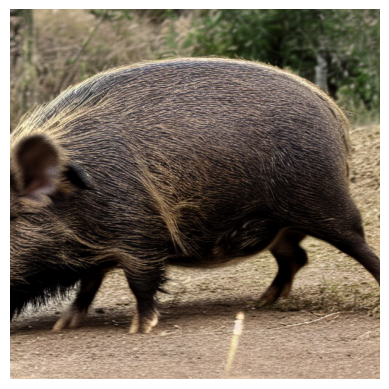

In [26]:
import torch
import matplotlib.pyplot as plt

x = img[0].detach().cpu()
if x.dtype == torch.uint8:
    arr = x.permute(1, 2, 0).numpy()      # HWC uint8 [0,255]
else:
    x = x.float()
    arr = x.permute(1, 2, 0).numpy()      # HWC float [0,1]

plt.imshow(arr)
plt.axis("off")